# day 08 | 250915

## herein

Today we will practice plotting with real data that would be gathered from some instrument and which you want to plot for your scientific notebook or for a paper. Now that we have the basics of plotting we need to practice this with some real data and see what trouble we run into. So today we will import and trim data, and then prepare some plots based on that data.  

To import some data to python, there are a variety of ways, each depending on how complex the data is. Today, we will start with a simple example of two columns of data in a file. The file extension is readable by python as simply a `comma separated value` or `csv` file. Many files that have various extensions are like this, and many/most experimental apparatus will have the ability to export data in such a format. 

After loading the data using `np.loadtxt()`, we have to take the transform of this file using `data.T`, and then we are able to use matplotlib to plot the data just like before.

Pandas has a more complicated but more capable function called `pd.read_csv()`. This is our first encounter with data stored as a pandas `dataframe` object, but we will practice how to use it to plot some data. 

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = np.loadtxt('../data/150407-02.dat', skiprows=1)

In [7]:
data[1]

array([28., 17., 23., ...,  8., 12.,  0.])

In [4]:
data = data.T

Text(0, 0.5, 'Intensity (a.u.)')

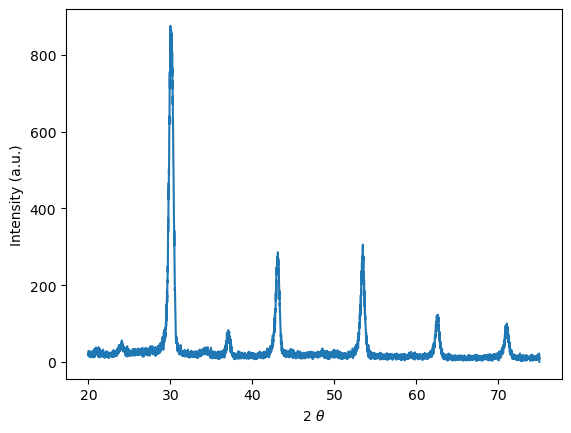

In [12]:
fig0 = plt.figure()
ax0 = fig0.add_subplot()

ax0.plot(data[0], data[1])

ax0.set_xlabel(r'2 $\theta$')
ax0.set_ylabel('Intensity (a.u.)')

In [13]:
fig0.savefig('../figs/150407-02-plot.png')

In [14]:
data1 = pd.read_csv('../data/170330-00.mpt', header=55, sep='\t', encoding='windows-1252')

In [15]:
data1

,freq/Hz,Re(Z)/Ohm,-Im(Z)/Ohm,|Z|/Ohm,Phase(Z)/deg,time/s,<Ewe>/V,<I>/mA,Cs/µF,Cp/µF,cycle number,I Range,|Ewe|/V,|I|/A,Re(Y)/Ohm-1,Im(Y)/Ohm-1,|Y|/Ohm-1,Phase(Y)/deg
0,7.000024e+06,895.75378,147.372860,907.79602,-9.342825,2.520596,0.000327,0.000038,0.000154,0.000004,1.0,40,0.007715,0.000008,0.001087,0.000179,0.001102,9.342825
1,5.551806e+06,978.20587,77.754303,981.29120,-4.544694,3.437591,-0.000015,0.000034,0.000369,0.000002,1.0,40,0.010245,0.000010,0.001016,0.000081,0.001019,4.544694
2,4.403234e+06,966.23254,76.227158,969.23468,-4.510785,3.546738,-0.000019,0.000036,0.000474,0.000003,1.0,40,0.010240,0.000011,0.001029,0.000081,0.001032,4.510785
3,3.492272e+06,968.32733,64.608551,970.48035,-3.817220,3.656734,-0.000012,0.000035,0.000705,0.000003,1.0,40,0.010122,0.000010,0.001028,0.000069,0.001030,3.817220
4,2.769775e+06,974.00806,62.624184,976.01923,-3.678788,3.866602,-0.000018,0.000030,0.000918,0.000004,1.0,40,0.010080,0.000010,0.001022,0.000066,0.001025,3.678788
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,2.526678e+00,5487.50390,466.635010,5507.30860,-4.860507,17.487966,0.000371,0.000024,134.987300,0.969100,1.0,41,0.010288,0.000002,0.000181,0.000015,0.000182,4.860507
65,2.003207e+00,5506.98240,372.655120,5519.57670,-3.871279,18.595106,0.000369,0.000013,213.199950,0.971829,1.0,42,0.010266,0.000002,0.000181,0.000012,0.000181,3.871279
66,1.589842e+00,5523.89450,295.391200,5531.78710,-3.060986,19.301461,0.000363,0.000012,338.897670,0.966346,1.0,42,0.010269,0.000002,0.000181,0.000010,0.000181,3.060986
67,1.261711e+00,5530.05370,236.371870,5535.10300,-2.447512,20.187411,0.000371,0.000012,533.659730,0.973206,1.0,42,0.010262,0.000002,0.000181,0.000008,0.000181,2.447512


In [16]:
data1.columns

Index(['freq/Hz', 'Re(Z)/Ohm', '-Im(Z)/Ohm', '|Z|/Ohm', 'Phase(Z)/deg',
       'time/s', '<Ewe>/V', '<I>/mA', 'Cs/µF', 'Cp/µF', 'cycle number',
       'I Range', '|Ewe|/V', '|I|/A', 'Re(Y)/Ohm-1', 'Im(Y)/Ohm-1',
       '|Y|/Ohm-1', 'Phase(Y)/deg'],
      dtype='object')

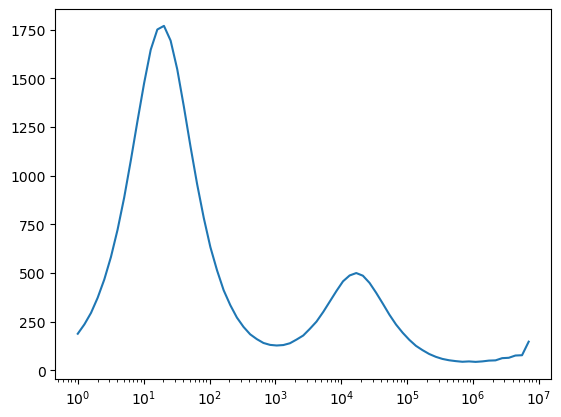

In [19]:
fig1 = plt.figure()
ax1 = fig1.add_subplot()

ax1.semilogx(data1['freq/Hz'], data1['-Im(Z)/Ohm'])

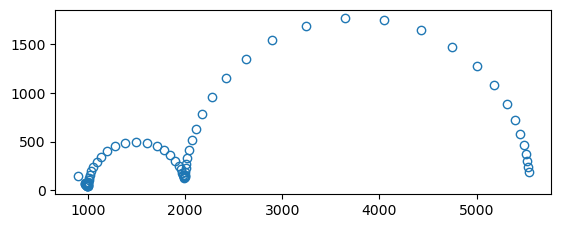

In [22]:
fig2 = plt.figure()
ax2 = fig2.add_subplot(aspect='equal')

ax2.plot(data1['Re(Z)/Ohm'], data1['-Im(Z)/Ohm'], 'o', mfc='none')

# homework problem exercise 3.1

This on is fine until you get to the rolling average part. Thankfully there is a library for that. Use pandas to load the data, then use the rolling().mean() method to implement. See below.

In [59]:
data3 = pd.read_csv('../data/sunspots.txt', sep='\t', names=['time','spots'])

In [60]:
data3

,time,spots
0,0,58.0
1,1,62.6
2,2,70.0
3,3,55.7
4,4,85.0
...,...,...
3138,3138,16.1
3139,3139,19.6
3140,3140,25.2
3141,3141,23.5


(0.0, 999.0)

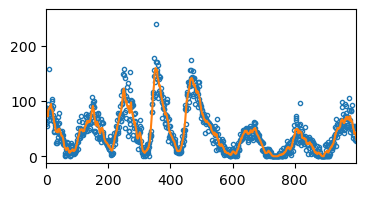

In [64]:
fig3 = plt.figure(figsize=(4,2))
ax3 = fig3.add_subplot()

ax3.plot(data3['time'], data3['spots'], '.', mfc='none')
ax3.plot(data3['time'], data3['spots'].rolling(10, center=True).mean())

ax3.set_xlim(0,999)